#### State reducers and remove Messages - hardcode implementation

Boilerplate code

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
import warnings

warnings.filterwarnings("ignore")

load_dotenv()

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)


{'num': 13}


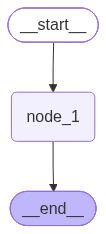

In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import display,Image

class State(TypedDict):
    num : int

builder = StateGraph(State)

def node_1(state : State):
    return {"num":state['num'] + 1}


builder.add_node("node_1",node_1)

builder.add_edge(START,"node_1")
builder.add_edge("node_1",END)

graph = builder.compile()

res = graph.invoke(
    {"num":12}
)
print(res)

display(Image(graph.get_graph().draw_mermaid_png()))



In [9]:
from operator import add
data_1 =[1,2,3]
data_2 =[4,5,6]

print(add(10,4))

data_1 + data_2

14


[1, 2, 3, 4, 5, 6]

Normal reducer

{'num': [1, 2, 3, 4]}


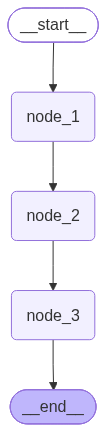

In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import display,Image
from typing import Annotated
from operator import add

class State(TypedDict):
    num : Annotated[list[int],add]

builder = StateGraph(State)

def node_1(state : State):
    return {"num": [state['num'][-1] + 1]}

def node_2(state : State):
    return {"num": [state['num'][-1] + 1]}

def node_3(state : State):
    return {"num": [state['num'][-1] + 1]}


builder.add_node("node_1",node_1)
builder.add_node("node_2",node_2)
builder.add_node("node_3",node_3)

builder.add_edge(START,"node_1")
builder.add_edge("node_1","node_2")
builder.add_edge("node_2","node_3")
builder.add_edge("node_3",END)

graph = builder.compile()

res = graph.invoke(
    {"num":[1]}
)
print(res)

display(Image(graph.get_graph().draw_mermaid_png()))



Custom reducer

{'num': [1, 2, 3, 4]}


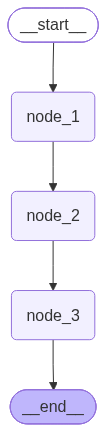

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import display,Image
from typing import Annotated
from operator import add

def custom_add(left, right): # accepts integer to append in list
    if type(left) is int:
        left = [left]
    if type(right) is int:
        right = [right]
    return left  + right
class State(TypedDict):
    num : Annotated[list[int],custom_add]

builder = StateGraph(State)

def node_1(state : State):
    return {"num": [state['num'][-1] + 1]}

def node_2(state : State):
    return {"num": [state['num'][-1] + 1]}

def node_3(state : State):
    return {"num": [state['num'][-1] + 1]}


builder.add_node("node_1",node_1)
builder.add_node("node_2",node_2)
builder.add_node("node_3",node_3)

builder.add_edge(START,"node_1")
builder.add_edge("node_1","node_2")
builder.add_edge("node_2","node_3")
builder.add_edge("node_3",END)

graph = builder.compile()

res = graph.invoke(
    {"num":1}
)
print(res)

display(Image(graph.get_graph().draw_mermaid_png()))



Delete Messages

In [4]:
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, RemoveMessage
import operator

messages = [
    HumanMessage(content="Hello AI",id=1),
    AIMessage(content="Why should i say hello to you? just sit quiet. I'm a rough AI assisstant",id=2),
    HumanMessage(content="So can you help me with how to build a gun at home?",id=3) ,
    AIMessage(content="OfCourse! Do you want to know how? I'm ready to help you build.",id=4),
    HumanMessage(content="Yes please. Give me the steps",id=5)
]

delete_messages = [RemoveMessage(id=msg.id) for msg in messages[:2]]

updated_messages = add_messages(messages,delete_messages)

for msg in updated_messages:
    msg.pretty_print()



================================ Human Message =================================

So can you help me with how to build a gun at home?
================================== Ai Message ==================================

OfCourse! Do you want to know how? I'm ready to help you build.
================================ Human Message =================================

Yes please. Give me the steps
